In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('combined_dataset.csv')
df.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df['Label'] = df['Label'].str.strip()
df['Label'] = df['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
})

df.columns = df.columns.str.strip() 
print(df.shape)
print(df['Label'].value_counts())

(2830743, 79)
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [5]:
drop_cols = [
    "Destination Port", 
    "Fwd Header Length.1", 
    "Init_Win_bytes_forward", 
    "Init_Win_bytes_backward"
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
print(df.columns)

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PS

In [9]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"NaNs drop: {df.isna().sum().sum()}")
df.dropna(inplace=True)
print(f"Shape after dropping: {df.shape}")

NaNs drop: 5734
Shape after dropping: (2827876, 75)


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import joblib
 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
 
torch.manual_seed(42)
np.random.seed(42)
 
device = torch.device("cuda" if torch.cuda.is_available() else "xpu")
print(f"Using device: {device}")
 

Using device: xpu


In [ ]:
label_col = "Label"
y = df[label_col].copy()
X = df.drop(columns=[label_col])
X = X.select_dtypes(include=[np.number])  # drop stray non-numeric leftovers
 
y_binary = (y != "BENIGN").astype(int)
 
print(f"Feature matrix shape: {X.shape}")
 
X_benign = X[y_binary == 0]
X_attack = X[y_binary == 1]
 
X_benign_train, X_benign_test = train_test_split(
    X_benign, test_size=0.3, random_state=42
)
X_benign_train, X_benign_val = train_test_split(
    X_benign_train, test_size=0.1, random_state=42
)
 
X_test = pd.concat([X_benign_test, X_attack])
y_test = pd.concat([
    pd.Series(np.zeros(len(X_benign_test)), index=X_benign_test.index),
    pd.Series(np.ones(len(X_attack)), index=X_attack.index)
])
 
print(f"Train (benign only): {X_benign_train.shape}")
print(f"Val (benign only): {X_benign_val.shape}")
print(f"Test (benign+attack): {X_test.shape}, attack ratio: {y_test.mean():.4f}")
 

Feature matrix shape: (2827876, 74)
Train (benign only): (1430931, 74)
Val (benign only): (158993, 74)
Test (benign+attack): (1237952, 74), attack ratio: 0.4496


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_benign_train).astype(np.float32)
X_val_scaled = scaler.transform(X_benign_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
 
n_features = X_train_scaled.shape[1]
print(f"Number of input features: {n_features}")

Number of input features: 74


In [13]:
BATCH_SIZE = 512
 
train_tensor = torch.from_numpy(X_train_scaled)
val_tensor = torch.from_numpy(X_val_scaled)
test_tensor = torch.from_numpy(X_test_scaled)
 
train_loader = DataLoader(TensorDataset(train_tensor, train_tensor),
                           batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor, val_tensor),
                         batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
        )
 
    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out
    

In [15]:
model = Autoencoder(n_features).to(device)
print(model)
 
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=74, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=74, bias=True)
  )
)


In [16]:
EPOCHS = 50
PATIENCE = 5
 
best_val_loss = float("inf")
patience_counter = 0
best_state = None
train_losses, val_losses = [], []
 
for epoch in range(1, EPOCHS + 1):
    # -- training --
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(train_loader.dataset)
 
    # -- validation --
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            val_running_loss += loss.item() * xb.size(0)
    val_loss = val_running_loss / len(val_loader.dataset)
 
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch:2d}/{EPOCHS} - train_loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")
      # -- early stopping --
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val_loss: {best_val_loss:.6f})")
            break

Epoch  1/50 - train_loss: 0.186351 - val_loss: 0.065214
Epoch  2/50 - train_loss: 0.103016 - val_loss: 0.053200
Epoch  3/50 - train_loss: 0.087181 - val_loss: 0.027964
Epoch  4/50 - train_loss: 0.067915 - val_loss: 0.044826
Epoch  5/50 - train_loss: 0.070873 - val_loss: 0.047736
Epoch  6/50 - train_loss: 0.061654 - val_loss: 0.025186
Epoch  7/50 - train_loss: 0.045140 - val_loss: 0.028940
Epoch  8/50 - train_loss: 0.051321 - val_loss: 0.042877
Epoch  9/50 - train_loss: 0.061251 - val_loss: 0.021881
Epoch 10/50 - train_loss: 0.056458 - val_loss: 0.022434
Epoch 11/50 - train_loss: 0.046884 - val_loss: 0.044517
Epoch 12/50 - train_loss: 0.051689 - val_loss: 0.035589
Epoch 13/50 - train_loss: 0.042304 - val_loss: 0.020248
Epoch 14/50 - train_loss: 0.094837 - val_loss: 0.023188
Epoch 15/50 - train_loss: 0.051978 - val_loss: 0.032425
Epoch 16/50 - train_loss: 0.055242 - val_loss: 0.024093
Epoch 17/50 - train_loss: 0.049889 - val_loss: 0.042576
Epoch 18/50 - train_loss: 0.060455 - val_loss: 0


Using custom threshold: 0.005481 (chosen to hit >= 80% recall)

=== Classification Report (BENIGN vs ATTACK) ===
              precision    recall  f1-score   support

      BENIGN       0.83      0.29      0.43    681396
      ATTACK       0.51      0.93      0.66    556556

    accuracy                           0.57   1237952
   macro avg       0.67      0.61      0.54   1237952
weighted avg       0.69      0.57      0.53   1237952


=== Confusion Matrix ===
[[194867 486529]
 [ 40359 516197]]

ROC-AUC: 0.6897
PR-AUC:  0.7340

=== Detection Rate by Attack Type ===
true_label
Web Attack - Sql Injection    1.000000
Web Attack - Brute Force      1.000000
Heartbleed                    1.000000
DoS Slowhttptest              0.999818
DoS slowloris                 0.999482
PortScan                      0.999326
SSH-Patator                   0.999152
FTP-Patator                   0.998614
DoS GoldenEye                 0.996600
Web Attack - XSS              0.973926
Infiltration             

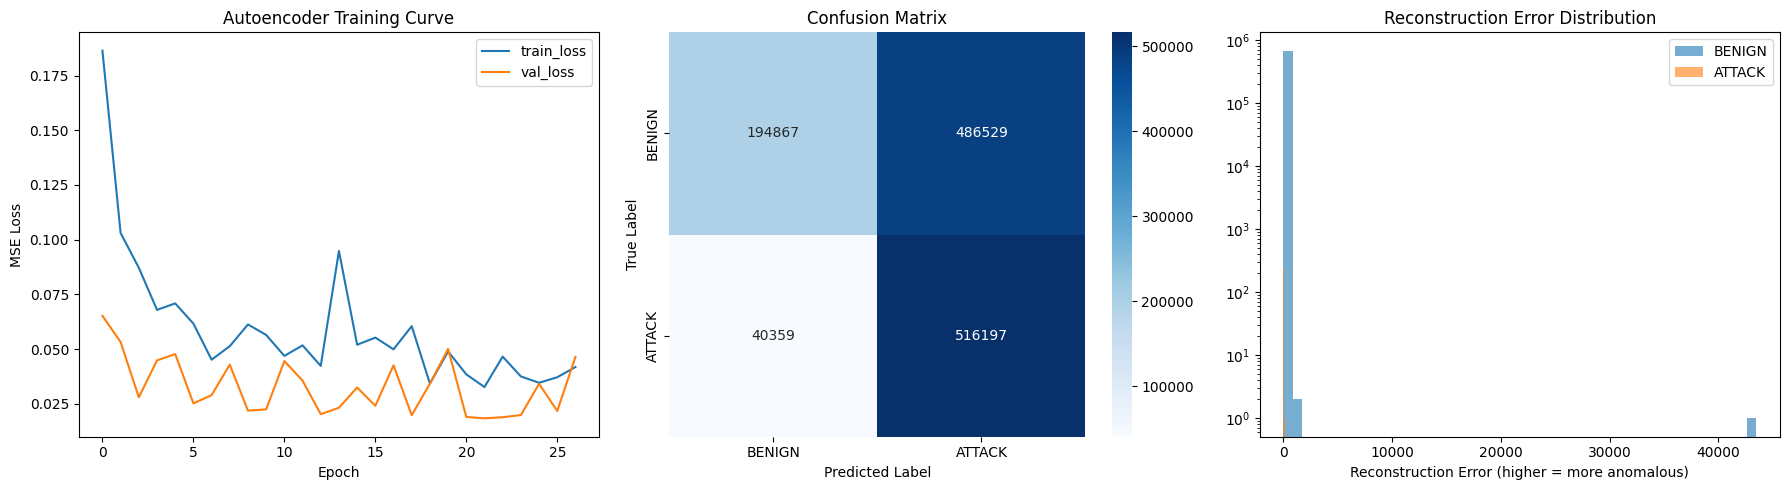

In [ ]:

 
# restore best weights
model.load_state_dict(best_state)
 
model.eval()
with torch.no_grad():
    test_tensor_dev = test_tensor.to(device)
    reconstructed = model(test_tensor_dev).cpu().numpy()
 
reconstruction_error = np.mean(np.square(X_test_scaled - reconstructed), axis=1)
anomaly_scores = reconstruction_error  # higher = more anomalous
 
precisions, recalls, thresholds = precision_recall_curve(y_test, anomaly_scores)
 
TARGET_RECALL = 0.80  # tune based on your operational needs
valid_idx = np.where(recalls[:-1] >= TARGET_RECALL)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precisions[valid_idx])]
    custom_threshold = thresholds[best_idx]
else:
    custom_threshold = np.median(anomaly_scores)
 
print(f"\nUsing custom threshold: {custom_threshold:.6f} "
      f"(chosen to hit >= {TARGET_RECALL*100:.0f}% recall)")
 
y_pred = (anomaly_scores >= custom_threshold).astype(int)
 
print("\n=== Classification Report (BENIGN vs ATTACK) ===")
print(classification_report(y_test, y_pred, target_names=["BENIGN", "ATTACK"]))
 
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)
 
roc_auc = roc_auc_score(y_test, anomaly_scores)
pr_auc = average_precision_score(y_test, anomaly_scores)
print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
 
results_df = pd.DataFrame({
    "true_label": y.loc[X_test.index],
    "predicted_anomaly": y_pred
}, index=X_test.index)
 
print("\n=== Detection Rate by Attack Type ===")
detection_rate = results_df.groupby("true_label")["predicted_anomaly"].mean().sort_values(ascending=False)
print(detection_rate)
 
print("\n=== Threshold options (recall vs precision tradeoff) ===")
for target_recall in [0.70, 0.80, 0.90, 0.95, 0.99]:
    valid = np.where(recalls[:-1] >= target_recall)[0]
    if len(valid) > 0:
        best = valid[np.argmax(precisions[valid])]
        print(f"Recall >= {target_recall:.2f}: threshold={thresholds[best]:.6f}, "
              f"precision={precisions[best]:.4f}")
    else:
        print(f"Recall >= {target_recall:.2f}: not achievable with this model")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(train_losses, label="train_loss")
axes[0].plot(val_losses, label="val_loss")
axes[0].set_title("Autoencoder Training Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
 
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["BENIGN", "ATTACK"], yticklabels=["BENIGN", "ATTACK"],
            ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
 
axes[2].hist(anomaly_scores[y_test == 0], bins=50, alpha=0.6, label="BENIGN")
axes[2].hist(anomaly_scores[y_test == 1], bins=50, alpha=0.6, label="ATTACK")
axes[2].set_title("Reconstruction Error Distribution")
axes[2].set_xlabel("Reconstruction Error (higher = more anomalous)")
axes[2].legend()
axes[2].set_yscale("log")
 
plt.tight_layout()
plt.savefig("autoencoder_pytorch_results.png", dpi=150)
print("\nSaved plot to autoencoder_pytorch_results.png")
 
torch.save(model.state_dict(), "autoencoder_ids_model.pt")
joblib.dump(scaler, "autoencoder_scaler.pkl")
print("\nSaved model to autoencoder_ids_model.pt and scaler to autoencoder_scaler.pkl")
print("To reload: model = Autoencoder(n_features); model.load_state_dict(torch.load('autoencoder_ids_model.pt'))")
 